В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

# Завдання 1

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Посилання на файл  
https://github.com/YatsiukTetiana/ML_DS_course/blob/main/process_bank_churn.py

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

from process_bank_churn import preprocess_data, preprocess_new_data

In [4]:
train_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

In [5]:
train_raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [6]:
# With MinMax scaling (default)
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(train_raw_df)

# Завдання 2

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay

In [91]:
import matplotlib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [13]:
model_tree = DecisionTreeClassifier(random_state=42)

In [14]:
%%time
model_tree.fit(X_train, y_train)

CPU times: user 89.2 ms, sys: 82 µs, total: 89.3 ms
Wall time: 95.4 ms


DecisionTreeClassifier(random_state=42)

In [20]:
def compute_auroc_and_build_roc(model, inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 1.00


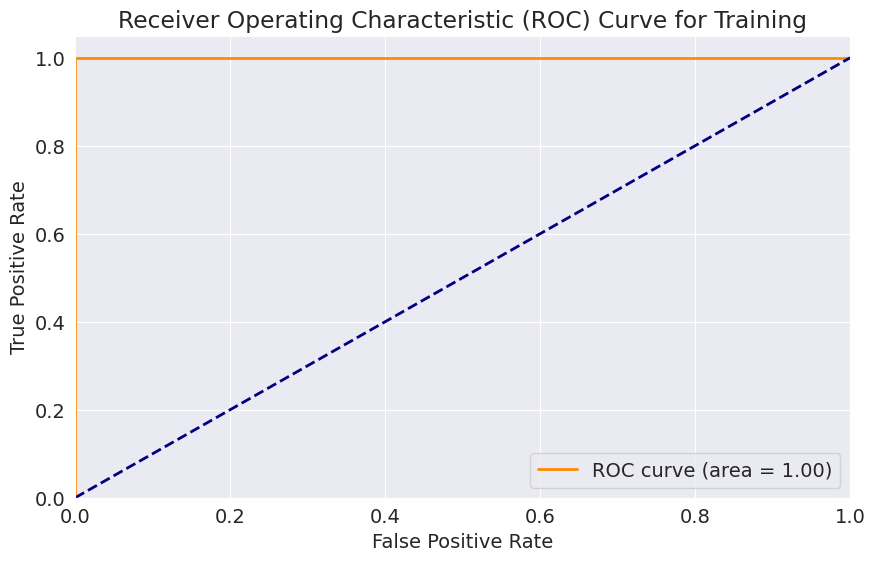

AUROC for Validation: 0.78


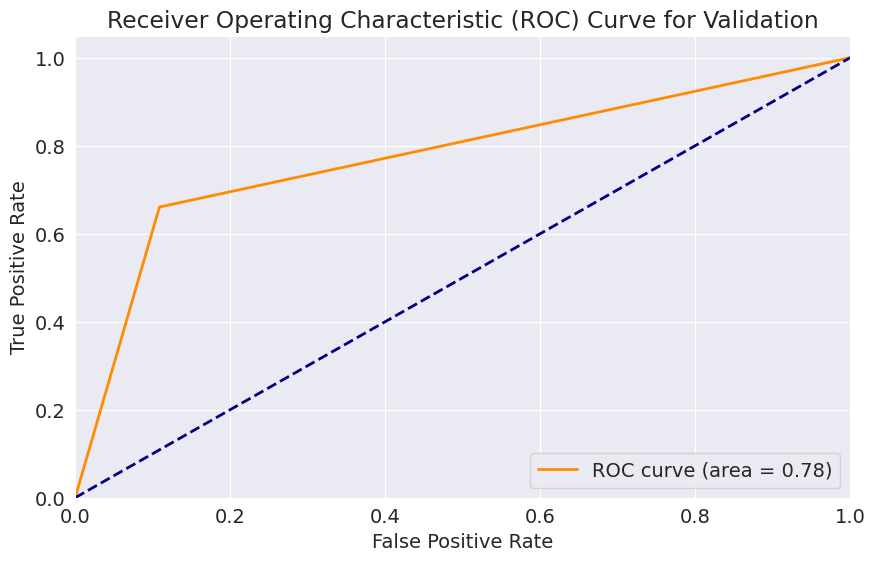

In [94]:
compute_auroc_and_build_roc(model_tree, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree, X_val, y_val, 'Validation')

Одразу видно перетренавчання моделі - на тренувальних даних AUROC = 1, на валідаційних = 0.78

In [25]:
#Глибина дерева
model_tree.tree_.max_depth

26

In [26]:
# Побудуємо дерево з максимальною глибиною 2
# Також визначимо найвпливовіші ознаки
model_tree_2 = DecisionTreeClassifier(max_depth=2, random_state=42)

In [27]:
%%time
model_tree_2.fit(X_train, y_train)

CPU times: user 14.6 ms, sys: 1.96 ms, total: 16.6 ms
Wall time: 17.5 ms


DecisionTreeClassifier(max_depth=2, random_state=42)

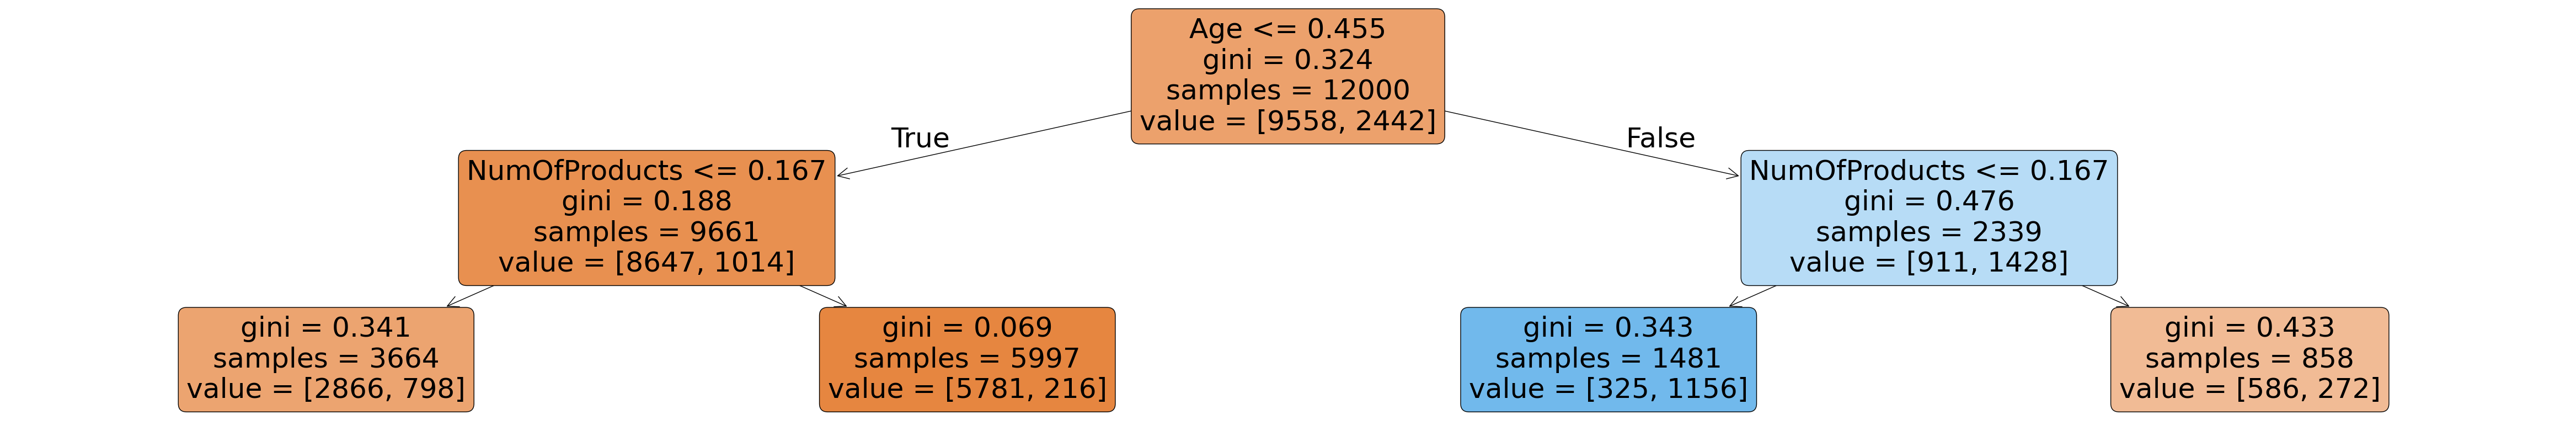

In [33]:
plt.figure(figsize=(60,10))
plot_tree(model_tree_2, feature_names=X_train.columns, filled=True, rounded=True);

,feature,importance
1,Age,0.354194
4,NumOfProducts,0.168379
7,EstimatedSalary,0.127802
0,CreditScore,0.123544
3,Balance,0.079601
2,Tenure,0.055563
6,IsActiveMember,0.033185
10,Gender_Male,0.018676
8,Geography_Germany,0.016288
5,HasCrCard,0.012669


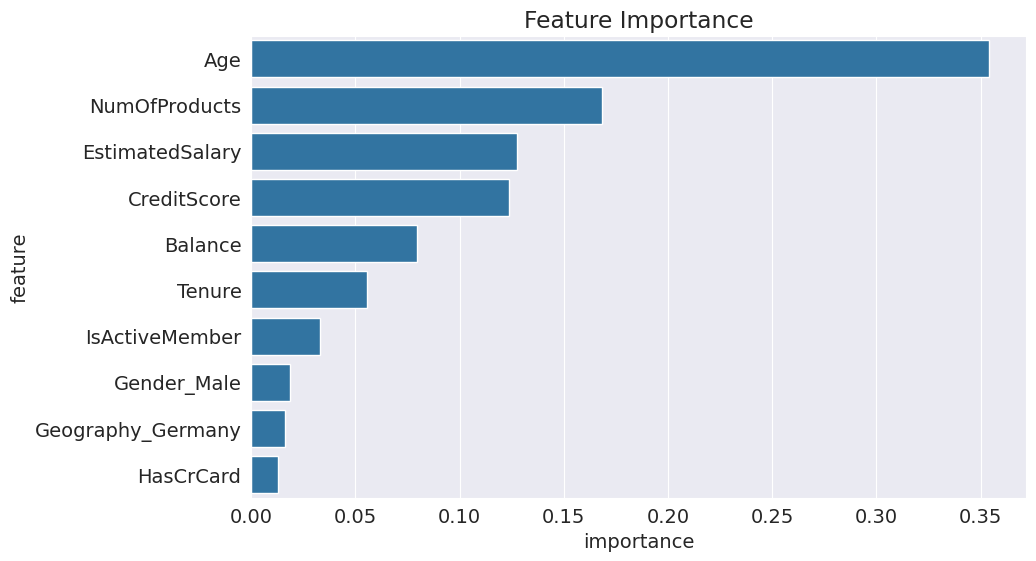

In [95]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_tree.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(10))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.show()

Бачимо, що найбільш впливовими ознаками (топ-4) відповідно до вузлів дерева та даних з моделі, є:  
1. Age
2. NumOfProducts
3. EstimatedSalary
4. CreditScore

# Завдання 3

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

## Max depth

In [54]:
model_tree_3 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_tree_5 = DecisionTreeClassifier(max_depth=10, random_state=42)
model_tree_6 = DecisionTreeClassifier(max_depth=15, random_state=42)
model_tree_7 = DecisionTreeClassifier(max_depth=4, random_state=42)

In [55]:
%%time
model_tree_3.fit(X_train, y_train)

CPU times: user 30.5 ms, sys: 1.93 ms, total: 32.4 ms
Wall time: 32.7 ms


DecisionTreeClassifier(max_depth=5, random_state=42)

In [56]:
%%time
model_tree_5.fit(X_train, y_train)

CPU times: user 53.7 ms, sys: 0 ns, total: 53.7 ms
Wall time: 54.9 ms


DecisionTreeClassifier(max_depth=10, random_state=42)

In [57]:
%%time
model_tree_6.fit(X_train, y_train)

CPU times: user 84.5 ms, sys: 868 µs, total: 85.3 ms
Wall time: 94.5 ms


DecisionTreeClassifier(max_depth=15, random_state=42)

In [58]:
%%time
model_tree_7.fit(X_train, y_train)

CPU times: user 32.7 ms, sys: 932 µs, total: 33.7 ms
Wall time: 92.6 ms


DecisionTreeClassifier(max_depth=4, random_state=42)

AUROC for Training: 0.93


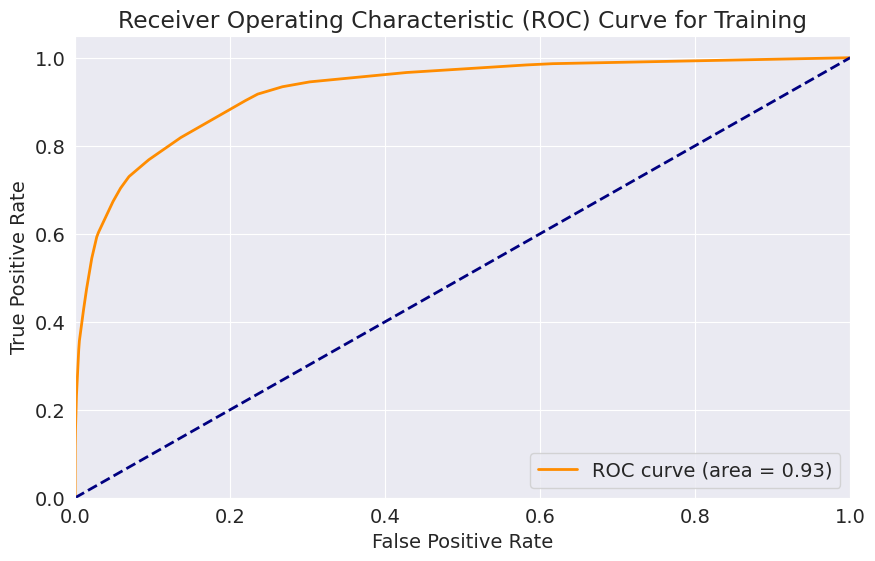

AUROC for Validation: 0.92


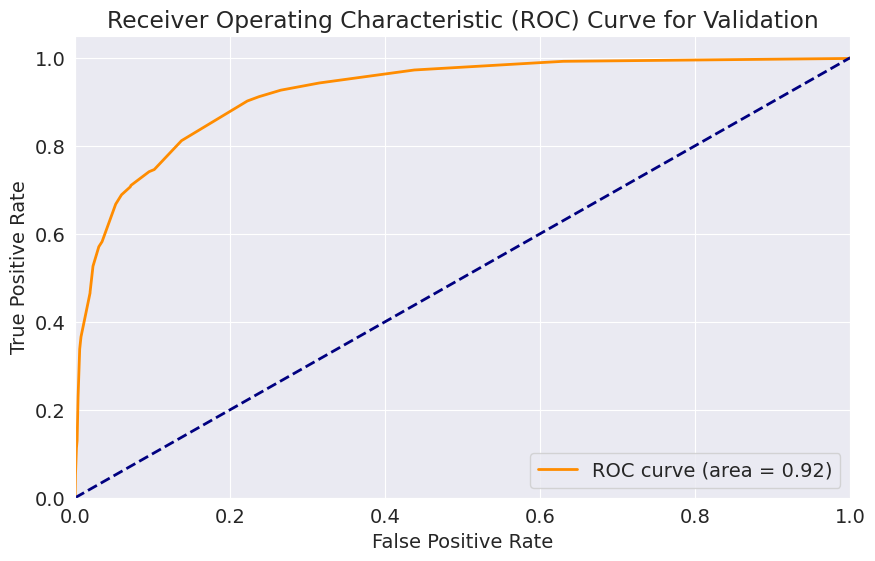

In [96]:
compute_auroc_and_build_roc(model_tree_3, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_3, X_val, y_val, 'Validation')

Бачимо досить хороший результат для глибини дерева 3. Тренувальна та валідаційна вибірки дають близькі значення AUROC 0.93 та 0.92

AUROC for Training: 0.97


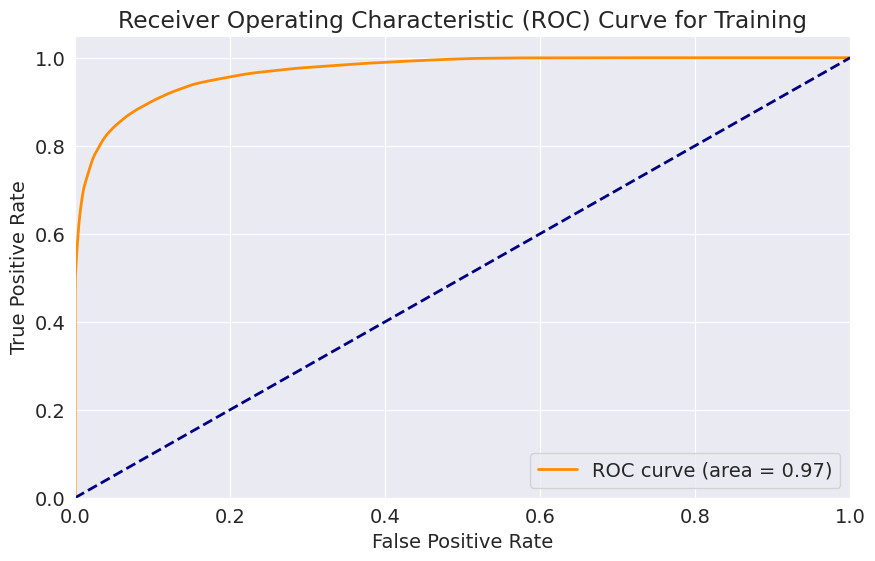

AUROC for Validation: 0.84


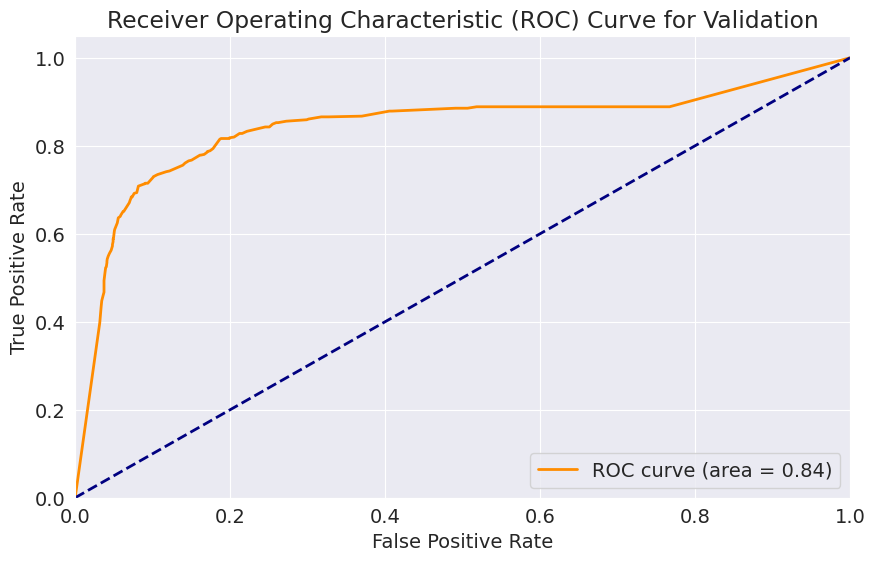

In [97]:
compute_auroc_and_build_roc(model_tree_5, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_5, X_val, y_val, 'Validation')

AUROC for Training: 1.00


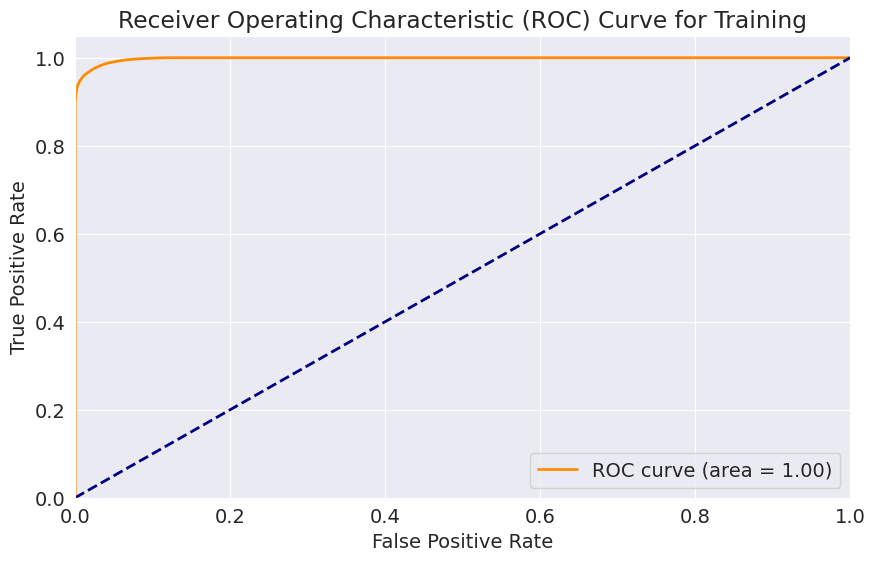

AUROC for Validation: 0.79


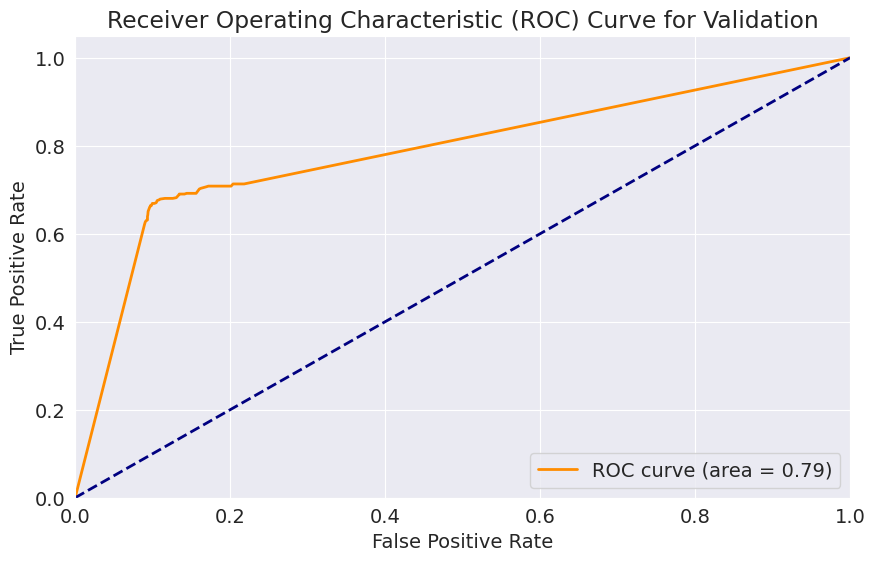

In [98]:
compute_auroc_and_build_roc(model_tree_6, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_6, X_val, y_val, 'Validation')

AUROC for Training: 0.91


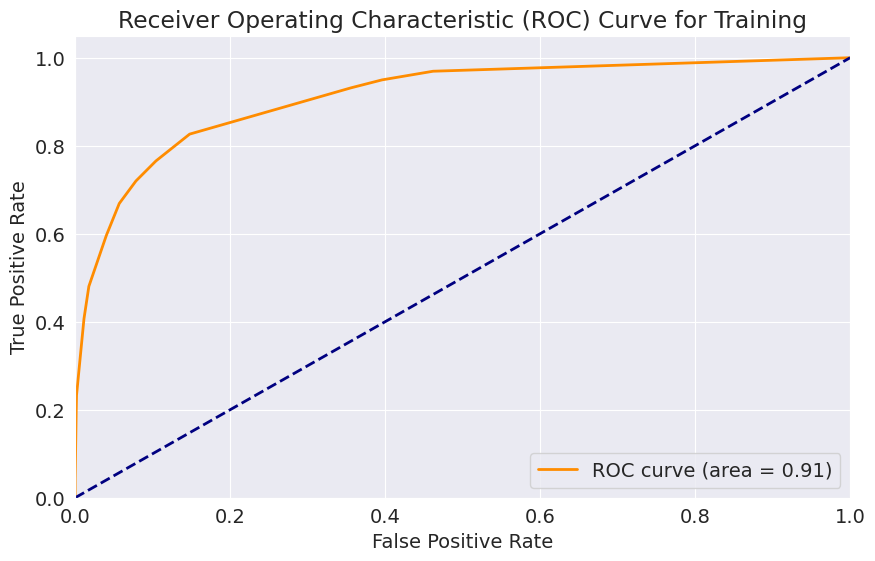

AUROC for Validation: 0.91


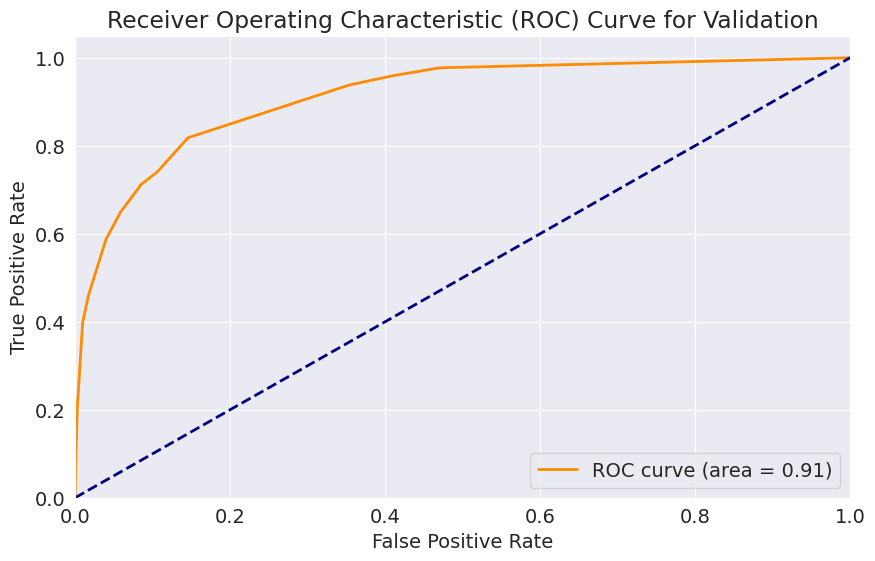

In [99]:
compute_auroc_and_build_roc(model_tree_7, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_7, X_val, y_val, 'Validation')

Найкращий результат отримали для глибини дерева 5

In [45]:
model_tree_3.tree_.n_leaves

np.int64(29)

## Max Leaf Nodes = 50

In [68]:
model_tree_4 = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)
model_tree_8 = DecisionTreeClassifier(max_leaf_nodes=40, random_state=42)
model_tree_9 = DecisionTreeClassifier(max_leaf_nodes=30, random_state=42)
model_tree_10 = DecisionTreeClassifier(max_leaf_nodes=100, random_state=42)

In [69]:
%%time
model_tree_4.fit(X_train, y_train)

CPU times: user 35.9 ms, sys: 0 ns, total: 35.9 ms
Wall time: 36 ms


DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

In [70]:
%%time
model_tree_8.fit(X_train, y_train)

CPU times: user 45.4 ms, sys: 0 ns, total: 45.4 ms
Wall time: 52.1 ms


DecisionTreeClassifier(max_leaf_nodes=40, random_state=42)

In [71]:
%%time
model_tree_9.fit(X_train, y_train)

CPU times: user 41.3 ms, sys: 640 µs, total: 41.9 ms
Wall time: 53.2 ms


DecisionTreeClassifier(max_leaf_nodes=30, random_state=42)

In [72]:
%%time
model_tree_10.fit(X_train, y_train)

CPU times: user 48.1 ms, sys: 0 ns, total: 48.1 ms
Wall time: 53.1 ms


DecisionTreeClassifier(max_leaf_nodes=100, random_state=42)

AUROC for Training: 0.93


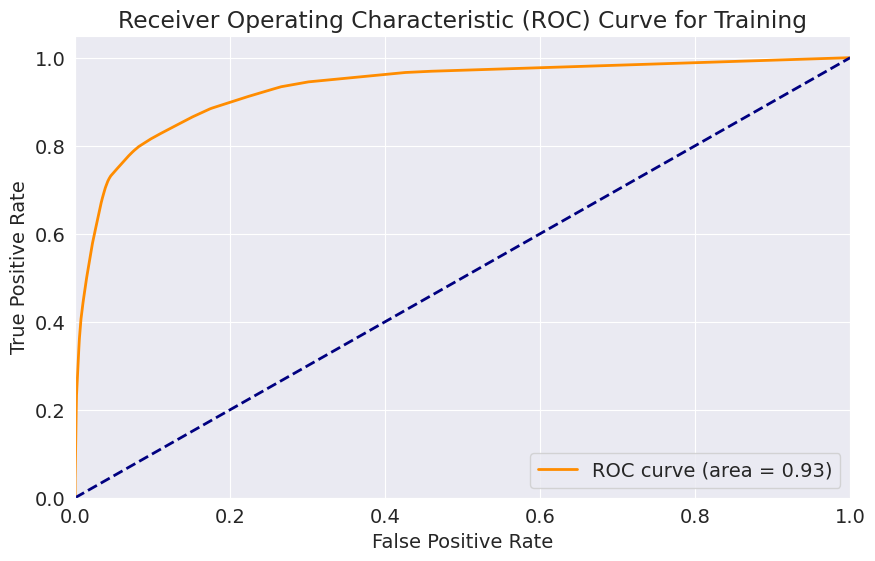

AUROC for Validation: 0.92


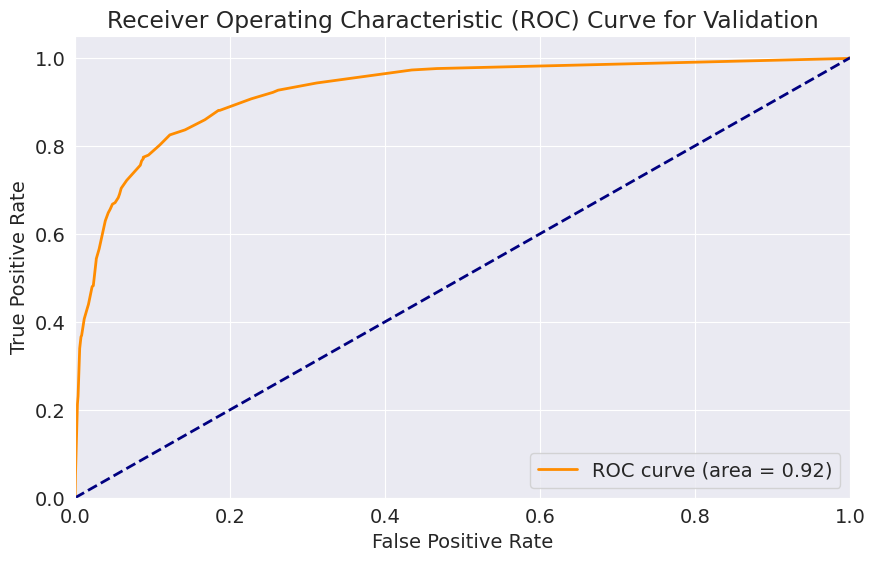

In [100]:
compute_auroc_and_build_roc(model_tree_4, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_4, X_val, y_val, 'Validation')

Результат аналогічний, як для дерева з глибиною 5

AUROC for Training: 0.93


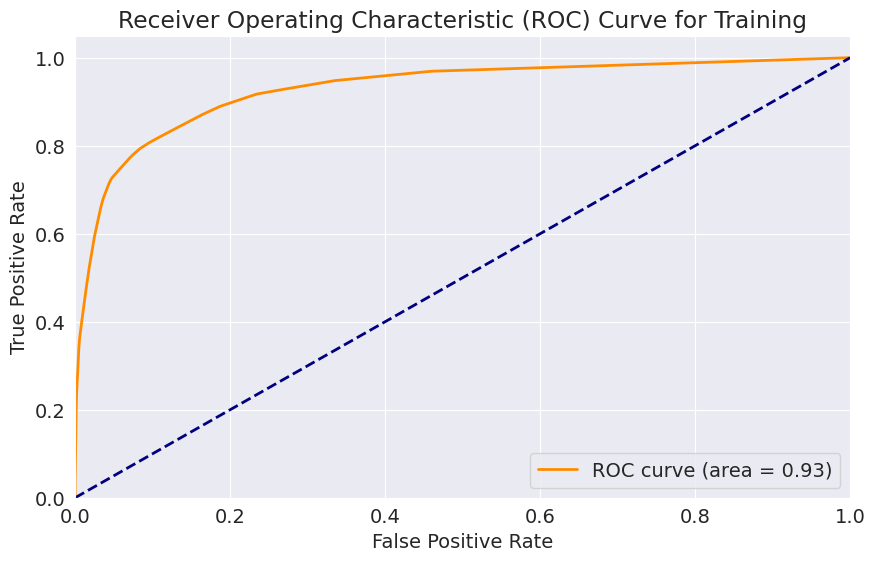

AUROC for Validation: 0.92


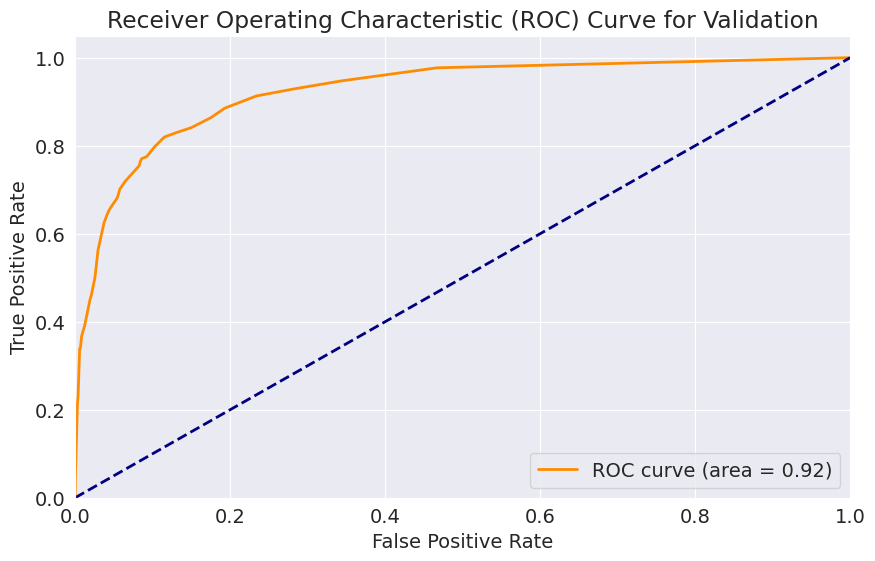

In [101]:
compute_auroc_and_build_roc(model_tree_8, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_8, X_val, y_val, 'Validation')

AUROC for Training: 0.92


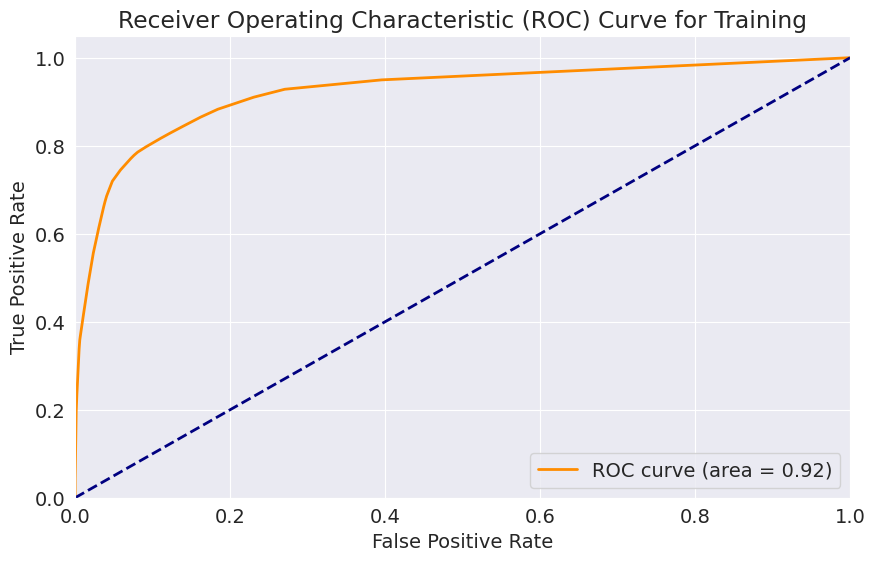

AUROC for Validation: 0.92


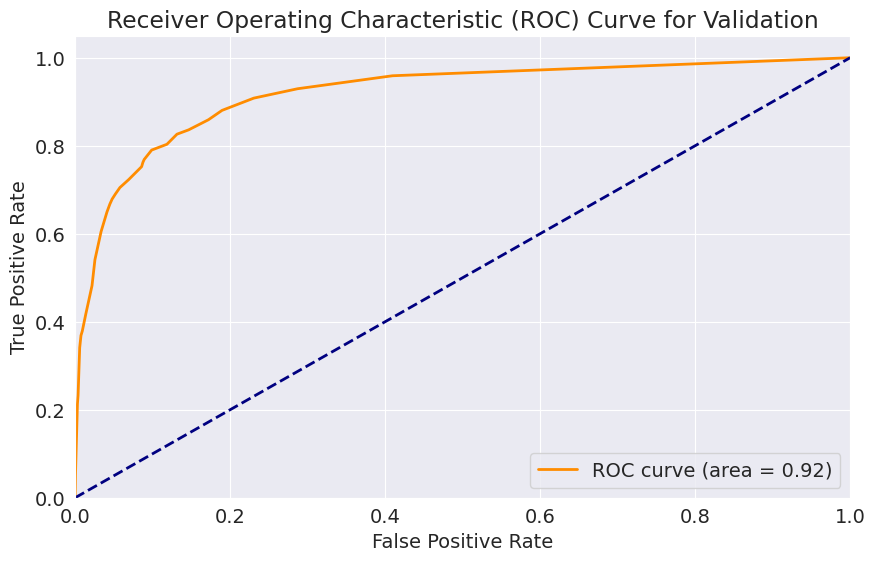

In [102]:
compute_auroc_and_build_roc(model_tree_9, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_9, X_val, y_val, 'Validation')

AUROC for Training: 0.94


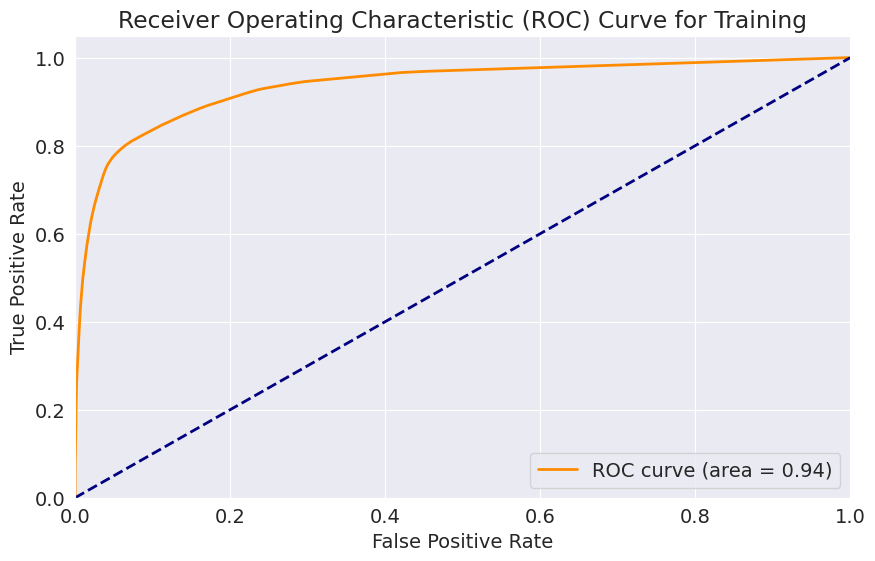

AUROC for Validation: 0.91


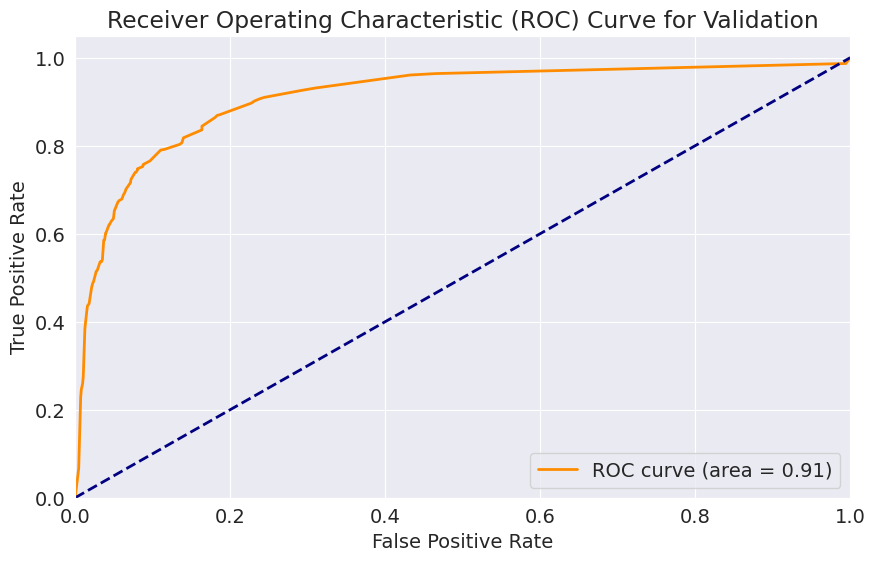

In [103]:
compute_auroc_and_build_roc(model_tree_10, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_10, X_val, y_val, 'Validation')

Глобально результат не змінюється для кількості листків в межах від 50 до 30. Для кількості 100 точність зменшується, виникають ознаки перенавчання

## Max Depth + Max Leaf Nodes

In [74]:
model_tree_11 = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=50, random_state=42)
model_tree_12 = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=20, random_state=42)
model_tree_13 = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=50, random_state=42)
model_tree_14 = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=80, random_state=42)

In [75]:
%%time
model_tree_11.fit(X_train, y_train)

CPU times: user 39.4 ms, sys: 0 ns, total: 39.4 ms
Wall time: 51.6 ms


DecisionTreeClassifier(max_depth=5, max_leaf_nodes=50, random_state=42)

In [76]:
%%time
model_tree_12.fit(X_train, y_train)

CPU times: user 36.5 ms, sys: 0 ns, total: 36.5 ms
Wall time: 125 ms


DecisionTreeClassifier(max_depth=5, max_leaf_nodes=20, random_state=42)

In [77]:
%%time
model_tree_13.fit(X_train, y_train)

CPU times: user 45.5 ms, sys: 0 ns, total: 45.5 ms
Wall time: 60.1 ms


DecisionTreeClassifier(max_depth=8, max_leaf_nodes=50, random_state=42)

In [78]:
%%time
model_tree_14.fit(X_train, y_train)

CPU times: user 47.2 ms, sys: 1 µs, total: 47.2 ms
Wall time: 51.3 ms


DecisionTreeClassifier(max_depth=8, max_leaf_nodes=80, random_state=42)

AUROC for Training: 0.93


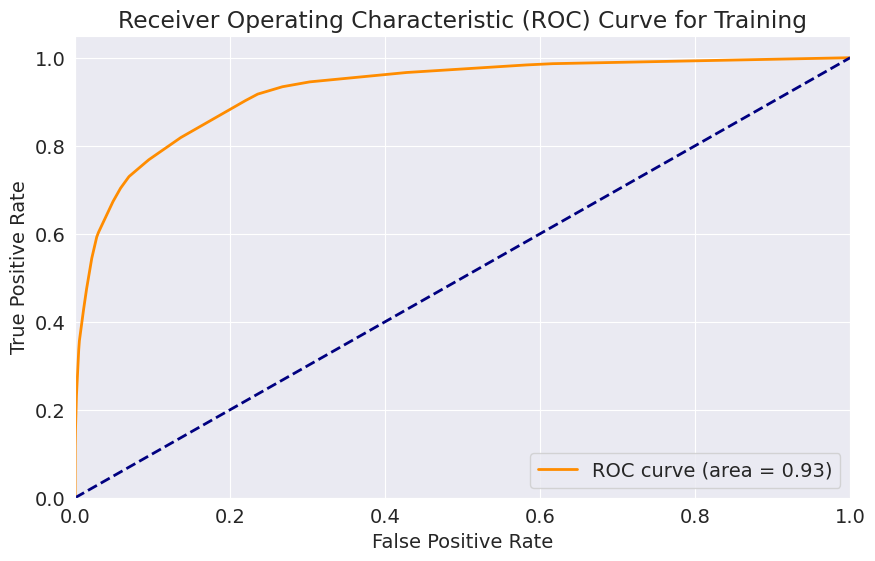

AUROC for Validation: 0.92


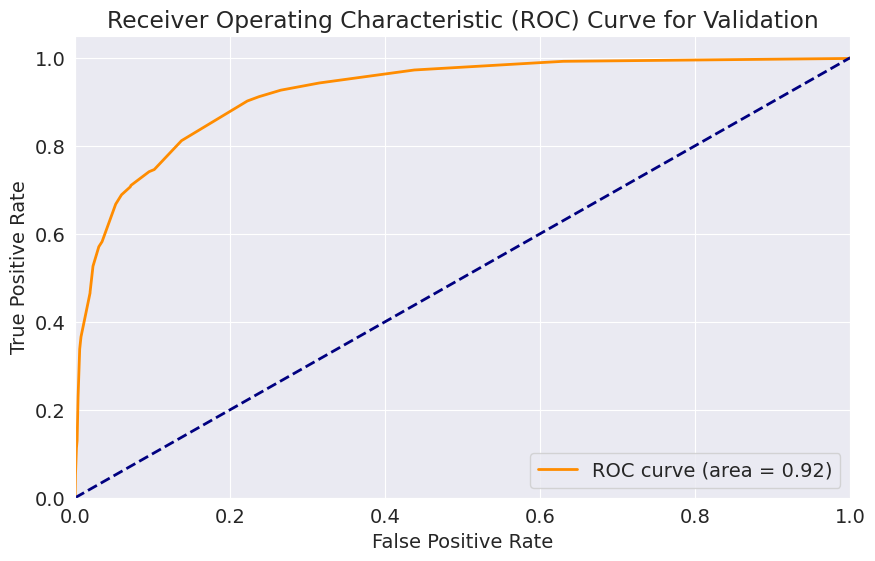

In [104]:
compute_auroc_and_build_roc(model_tree_11, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_11, X_val, y_val, 'Validation')

AUROC for Training: 0.92


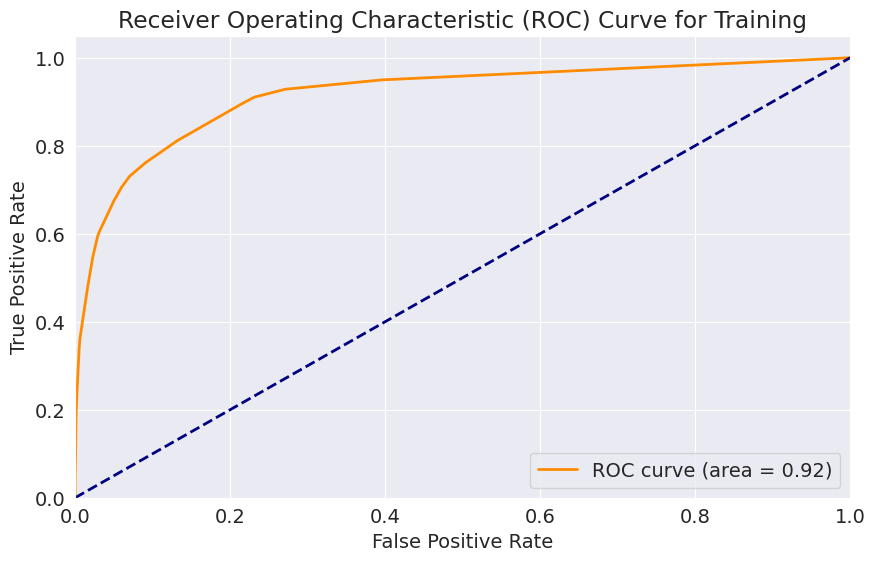

AUROC for Validation: 0.92


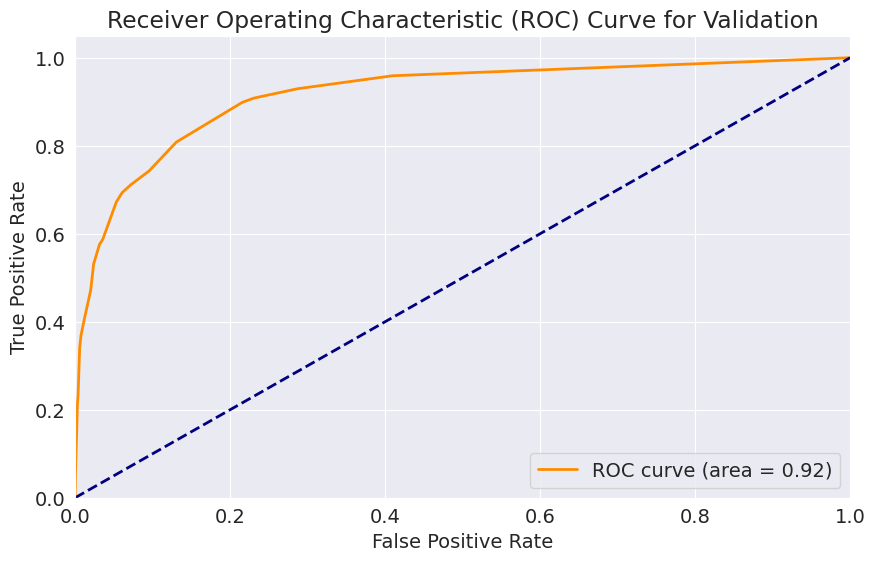

In [105]:
compute_auroc_and_build_roc(model_tree_12, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_12, X_val, y_val, 'Validation')

AUROC for Training: 0.93


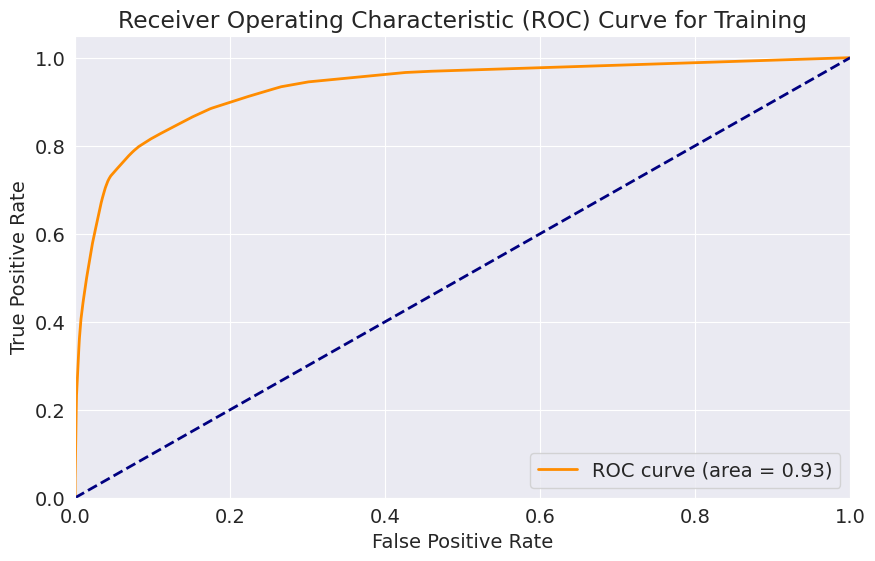

AUROC for Validation: 0.92


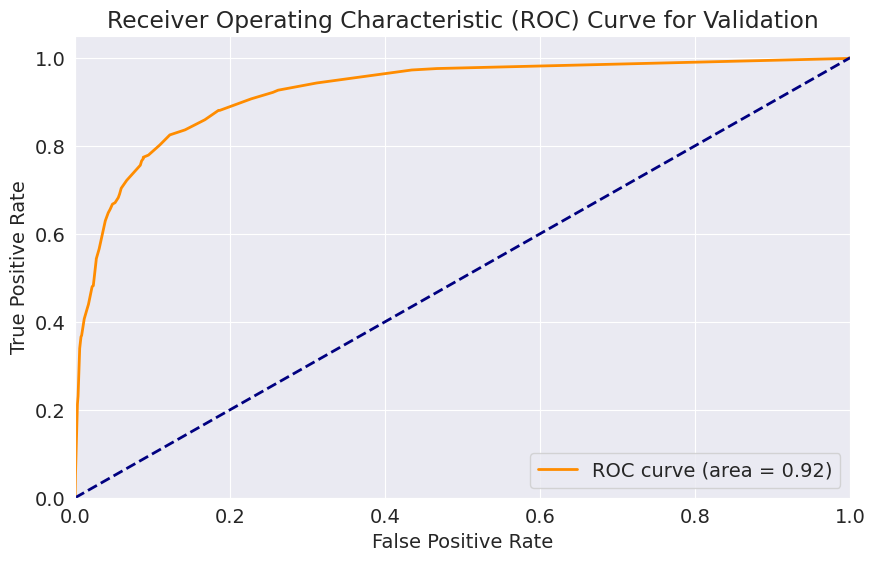

In [106]:
compute_auroc_and_build_roc(model_tree_13, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_13, X_val, y_val, 'Validation')

AUROC for Training: 0.94


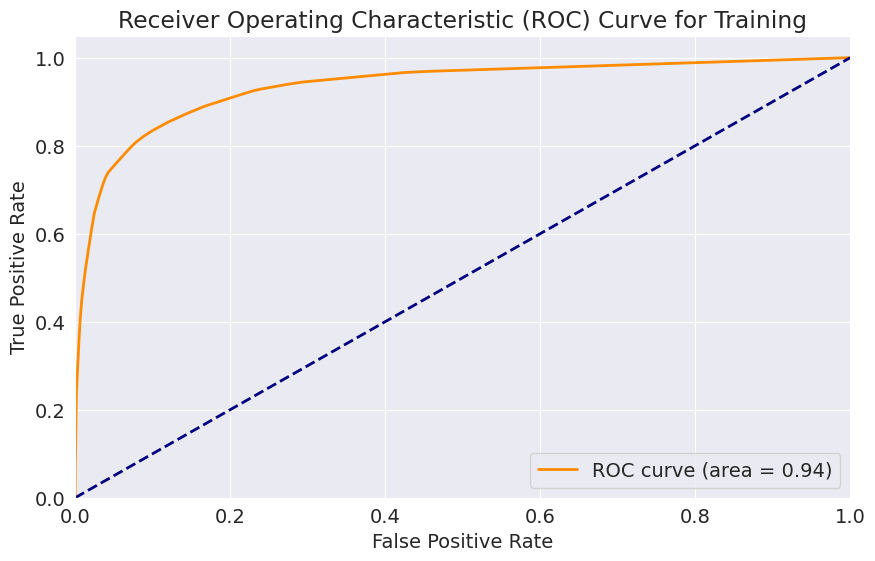

AUROC for Validation: 0.92


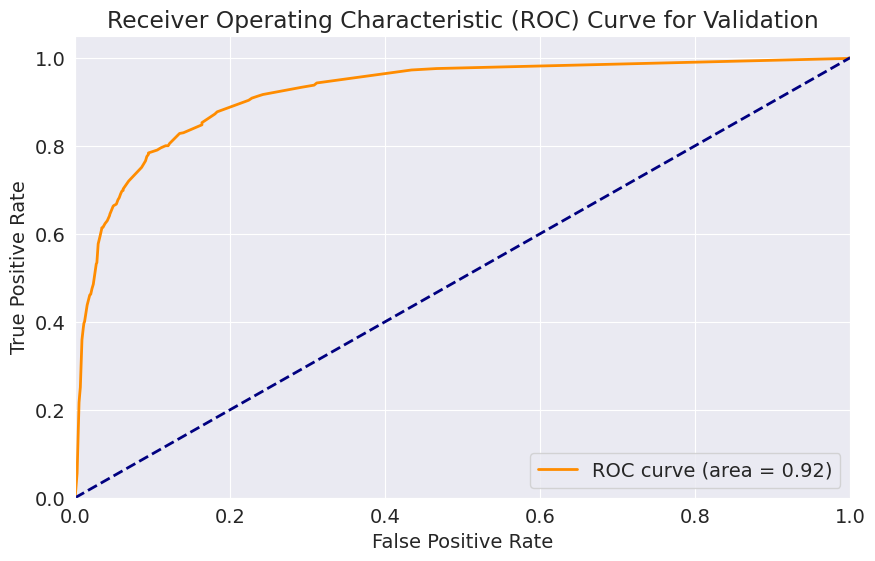

In [107]:
compute_auroc_and_build_roc(model_tree_14, X_train, y_train, 'Training')
compute_auroc_and_build_roc(model_tree_14, X_val, y_val, 'Validation')

Бачимо, що кращими параметрами, підібраними вручну, є глибина дерева 5 та кількість листя близько 20. Для моделі з глибиною 5 кількість листя становить 29, що теж має непогані показники.

# Завдання 4

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [83]:
def compute_auroc(model, inputs, targets):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  return roc_auc

In [84]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)

    train_auroc = compute_auroc(model, X_train, y_train)
    val_auroc = compute_auroc(model, X_val, y_val)

    return {'Max Depth': md, 'Training AUROC': train_auroc, 'Validation AUROC': val_auroc}

In [85]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: user 1.11 s, sys: 494 µs, total: 1.11 s
Wall time: 1.12 s


In [108]:
errors_df.style.background_gradient(subset='Validation AUROC', cmap='Blues_r')

,Max Depth,Training AUROC,Validation AUROC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925694,0.921927
5,6,0.933687,0.920216
6,7,0.941508,0.914359
7,8,0.949355,0.900384
8,9,0.958598,0.887294
9,10,0.969334,0.843292


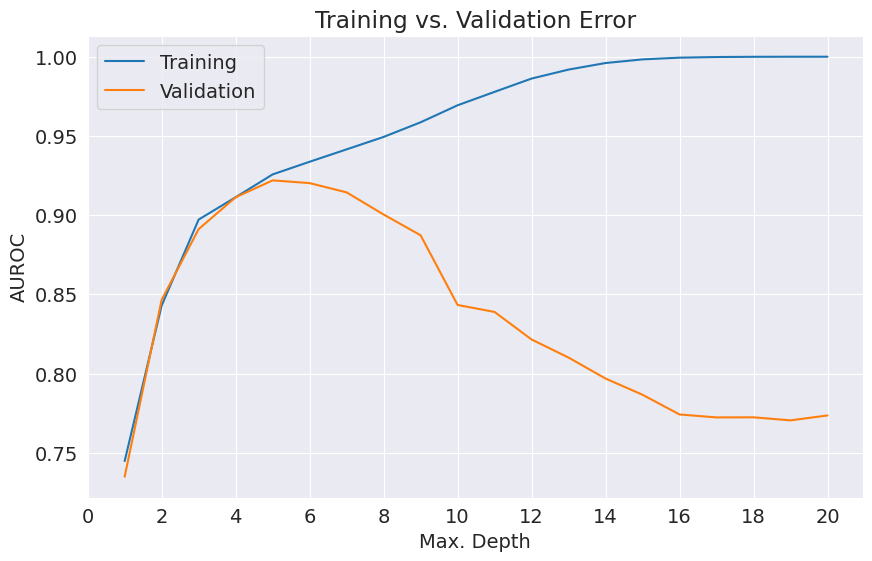

In [92]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training AUROC'])
plt.plot(errors_df['Max Depth'], errors_df['Validation AUROC'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

Отримали результат, що найкращі результати для тренувальної та валідаційної вибірки без виникнення перенавчання отримується при глибині дерева 5 (це ж саме було отримано вручну)

# Завдання 5

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [109]:
model_tree_winner = DecisionTreeClassifier(max_depth=5, random_state=42)

In [110]:
model_tree_winner.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [111]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/test.csv')

In [112]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [145]:
test_data = preprocess_new_data(test_raw_df, input_cols, scaler, encoder)

In [122]:
test_data['Exited'] = model_tree_winner.predict_proba(test_data)[:, 1]

In [123]:
test_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,0.365155,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,1.0,0.0,1.0,0.237911
1,0.286396,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,0.0,0.0,1.0,0.027613
2,0.656325,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,0.0,0.0,1.0,0.027613
3,0.682578,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,1.0,1.0,0.770925
4,0.384248,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,1.0,1.0,0.027613


In [124]:
submission_log_reg_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/sample_submission.csv')

In [126]:
submission_log_reg_df['Exited'] = test_data['Exited']

In [127]:
submission_log_reg_df.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613


In [128]:
save_path = '/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/'
submission_log_reg_df.to_csv(save_path + 'submission_log_reg.csv', index=False)

In [129]:
df=pd.read_csv(save_path+"submission_log_reg.csv")
df.columns
df.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613


Новий submission показав гірші результати, ніж попередній з використанням логістичної регресії  
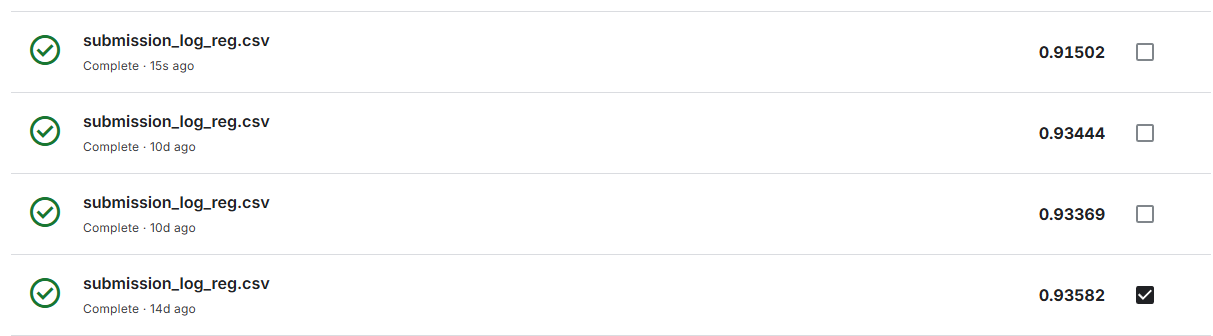

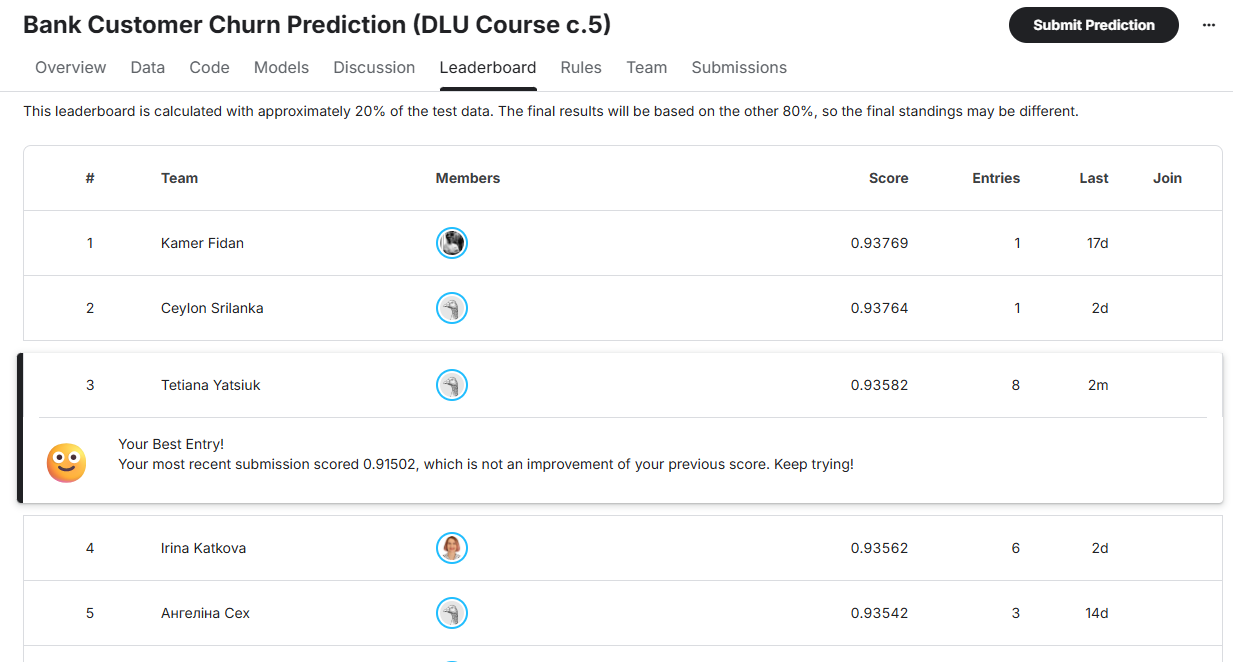

Спробуємо вдосконалити дерево з використанням prunning

In [131]:
model_tree_prun = DecisionTreeClassifier(random_state=42)
path = model_tree_prun.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

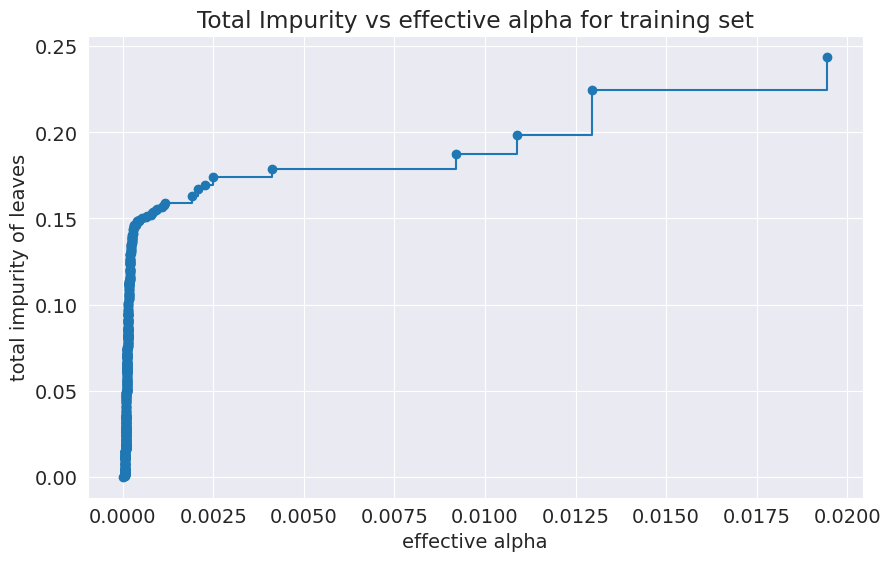

In [132]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set");

In [133]:
models = []
for ccp_alpha in ccp_alphas[-10:]:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    models.append(model)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        models[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08021653632155296


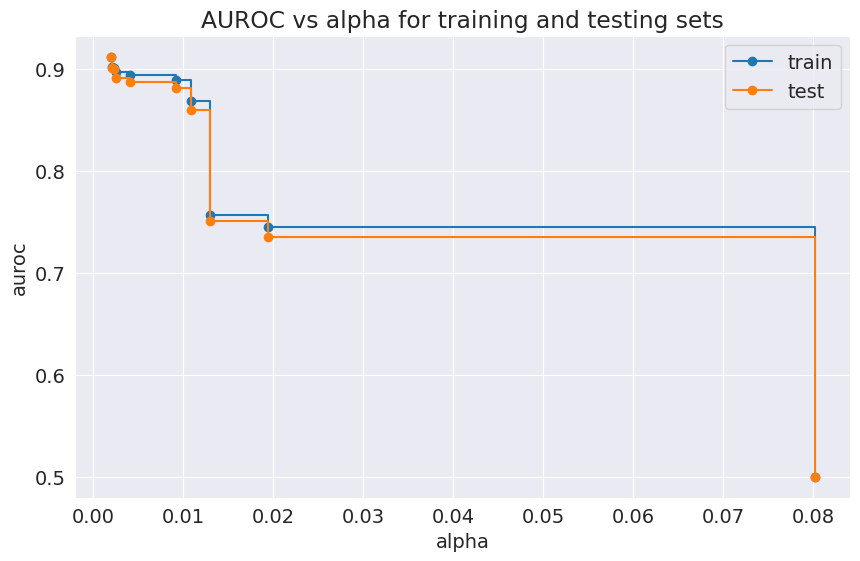

In [135]:
train_scores = [compute_auroc(model, X_train, y_train) for model in models]
val_scores = [compute_auroc(model, X_val, y_val) for model in models]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("auroc")
ax.set_title("AUROC vs alpha for training and testing sets")
ax.plot(ccp_alphas[-10:], train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[-10:], val_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [138]:
model_alpha = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alphas[-20])
model_alpha.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006505363696552319),
                       random_state=42)

In [139]:
model_alpha.tree_.max_depth

8

In [142]:
compute_auroc(model_alpha, X_train, y_train)

np.float64(0.9200928372303137)

In [143]:
compute_auroc(model_alpha, X_val, y_val)

np.float64(0.9192616091638659)

Отримали гірші показники AUROC

In [146]:
test_data['Exited'] = model_alpha.predict_proba(test_data)[:, 1]

In [147]:
test_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,0.365155,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,1.0,0.0,1.0,0.237911
1,0.286396,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,0.0,0.0,1.0,0.020862
2,0.656325,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,0.0,0.0,1.0,0.020862
3,0.682578,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,1.0,1.0,0.748954
4,0.384248,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,1.0,1.0,0.020862


In [148]:
submission_log_reg_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/sample_submission.csv')

In [149]:
submission_log_reg_df['Exited'] = test_data['Exited']

In [150]:
submission_log_reg_df.head()

,id,Exited
0,15000,0.237911
1,15001,0.020862
2,15002,0.020862
3,15003,0.748954
4,15004,0.020862


In [151]:
save_path = '/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/'
submission_log_reg_df.to_csv(save_path + 'submission_log_reg.csv', index=False)

Результати гірші
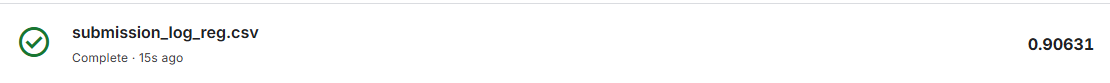